<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/Regression/Support_Vector_Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import libraries

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing dataset

In [85]:
df = pd.read_csv("/content/Position_Salaries.csv")
X = df.iloc[:, 1: -1].values
y = df.iloc[:, -1].values

##Feature Scaling

Need to scale the target variable also because the salary value are very high,

so initially we need to apply:



1.   y.reshape(len(y), 1)
2.   new StandardScaler for y as standard_deviation(y) and mean(y) can be different from Standard_deviation(X) and mean(X)




In [86]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X = sc_X.fit_transform(X)

sc_y = StandardScaler()
y = y.reshape(len(y), 1)  # same as y.reshape(-1, 1)
y = sc_y.fit_transform(y)

##Training the SVR model on the whole dataset

In [88]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X, y)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

##Predict the result

first use ***sc_y.inverse_transform()*** to transform the y back then predict and then at last also reshape(-1, 1)

***sc_y.inverse_transform(reg.predict(sc_X.transform([[6.5]])).reshape(-1, 1))***



In [89]:
sc_y.inverse_transform(regressor.predict(sc_X.transform([[6.5]])).reshape(-1, 1))

array([[170370.0204065]])

##Visualising SVR results

inverse_transform(X & y) to get the original results

In [93]:
X_inverse_transformed = sc_X.inverse_transform(X)
y_inverse_transformed = sc_y.inverse_transform(y)

Text(0, 0.5, 'Salary')

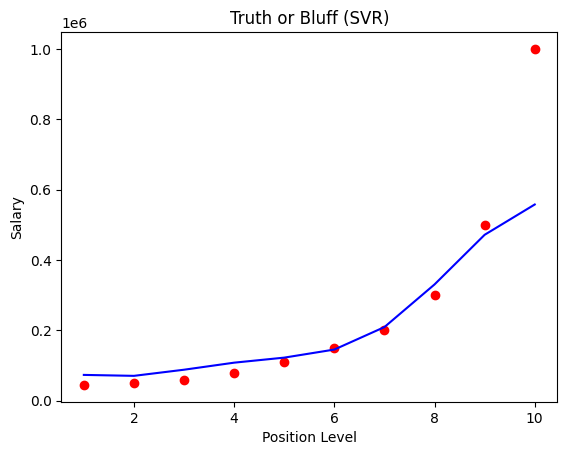

In [95]:
plt.scatter(X_inverse_transformed, y_inverse_transformed, color = "red")
plt.plot(X_inverse_transformed, sc_y.inverse_transform(regressor.predict(X).reshape(-1, 1)), color = "blue")

plt.title("Truth or Bluff (SVR)")

plt.xlabel("Position Level")
plt.ylabel("Salary")